<a href="https://colab.research.google.com/github/eacharan21/Impact-of-Normalization-on-Linear-Regression/blob/main/Effects_of_Normalization_Techniques_on_Linear_Regression_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_original=pd.read_excel("/content/drive/MyDrive/Chennai Weather.xlsx")
df_original.head()

,Date,ALLSKY_SFC_SW_DWN,RH2M,PRECTOTCORR,T2M_MAX,T2M_MIN,WS2M
0,1990-01-01,13.63,82.00,1.65,27.77,22.46,2.58
1,1990-01-02,16.63,79.69,0.15,27.68,22.20,3.18
2,1990-01-03,16.33,80.08,0.21,27.63,22.46,3.61
3,1990-01-04,16.57,76.79,0.30,27.39,21.71,4.27
4,1990-01-05,14.74,76.64,0.06,26.81,20.55,4.45


### Preprocessing

In [ ]:
df_original.rename(columns={
    'T2M_MAX': 'Max_temp',
    'T2M_MIN': 'Min_temp',
    'RH2M': 'Humidity',
    'PRECTOTCORR': 'Rain',
    'WS2M': 'Wind_speed',
    'ALLSKY_SFC_SW_DWN': 'Radiation'},inplace=True)
df_original.head()

,Date,Radiation,Humidity,Rain,Max_temp,Min_temp,Wind_speed
0,1990-01-01,13.63,82.00,1.65,27.77,22.46,2.58
1,1990-01-02,16.63,79.69,0.15,27.68,22.20,3.18
2,1990-01-03,16.33,80.08,0.21,27.63,22.46,3.61
3,1990-01-04,16.57,76.79,0.30,27.39,21.71,4.27
4,1990-01-05,14.74,76.64,0.06,26.81,20.55,4.45


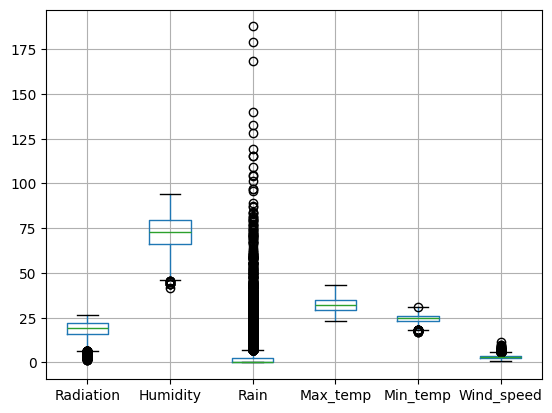

In [ ]:
df_original.boxplot()
plt.show()

### Import libraries and Data

In [ ]:
df_original.isna().sum()

,0
Date,0
Radiation,0
Humidity,0
Rain,0
Max_temp,0
Min_temp,0
Wind_speed,0


In [ ]:
numerical_cols=df_original.select_dtypes(include=['float64','int64']).columns
for col in numerical_cols:
    Q1=df_original[col].quantile(0.25)
    Q3=df_original[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    print(f"Column: {col}")
    print(f"  Lower Bound : {lower_bound}")
    print(f"  Upper Bound : {upper_bound}")
    outliers=df_original[(df_original[col]<lower_bound)|(df_original[col]>upper_bound)]
    print(f"  Number of outliers: {len(outliers)}")
    print()

Column: Radiation
  Lower Bound : 6.504999999999997
  Upper Bound : 31.265
  Number of outliers: 281

Column: Humidity
  Lower Bound : 45.52875
  Upper Bound : 99.89875
  Number of outliers: 12

Column: Rain
  Lower Bound : -4.035
  Upper Bound : 6.725
  Number of outliers: 1842

Column: Max_temp
  Lower Bound : 20.335000000000004
  Upper Bound : 43.815
  Number of outliers: 0

Column: Min_temp
  Lower Bound : 18.305
  Upper Bound : 30.824999999999996
  Number of outliers: 35

Column: Wind_speed
  Lower Bound : 0.6750000000000003
  Upper Bound : 5.515000000000001
  Number of outliers: 159



In [ ]:
df_cleaned = df_original.copy()
cols_cap = ['Humidity', 'Max_temp', 'Min_temp', 'Wind_speed']
for col in cols_cap:
  Q1 = df_cleaned[col].quantile(0.25)
  Q3 = df_cleaned[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_cleaned[col] = df_cleaned[col].clip(
  lower=lower_bound,upper=upper_bound)
df_cleaned['Rain'] = np.log1p(df_cleaned['Rain'])

In [ ]:
df_cleaned=pd.DataFrame(df_cleaned)

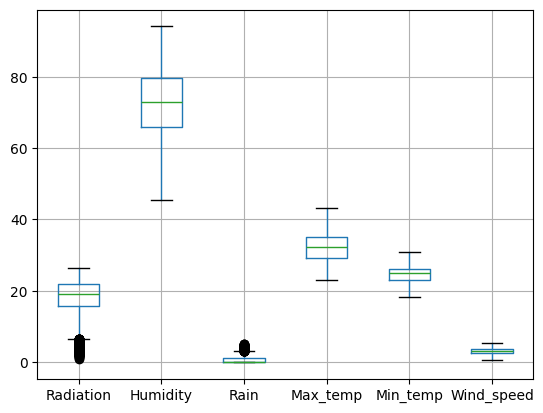

In [ ]:
df_cleaned.boxplot()
plt.show()

In [ ]:
df_cleaned.head()

,Date,Radiation,Humidity,Rain,Max_temp,Min_temp,Wind_speed
0,1990-01-01,13.63,82.00,0.974560,27.77,22.46,2.58
1,1990-01-02,16.63,79.69,0.139762,27.68,22.20,3.18
2,1990-01-03,16.33,80.08,0.190620,27.63,22.46,3.61
3,1990-01-04,16.57,76.79,0.262364,27.39,21.71,4.27
4,1990-01-05,14.74,76.64,0.058269,26.81,20.55,4.45


### EDA

In [ ]:
df_cleaned.describe()

,Date,Radiation,Humidity,Rain,Max_temp,Min_temp,Wind_speed
count,13088,13088.000000,13088.000000,13088.000000,13088.000000,13088.000000,13088.000000
mean,2007-12-01 12:00:00,18.352398,72.587173,0.767610,32.265458,24.585664,3.118743
min,1990-01-01 00:00:00,1.040000,45.528750,0.000000,22.990000,18.305000,0.790000
25%,1998-12-16 18:00:00,15.790000,65.917500,0.000000,29.140000,23.000000,2.490000
50%,2007-12-01 12:00:00,19.180000,72.755000,0.231112,32.270000,25.060000,3.050000
75%,2016-11-15 06:00:00,21.980000,79.510000,1.305626,35.010000,26.130000,3.700000
max,2025-10-31 00:00:00,26.440000,94.080000,5.241112,43.340000,30.825000,5.515000
std,NaN,4.648413,9.007383,1.007472,3.509368,2.364006,0.902137


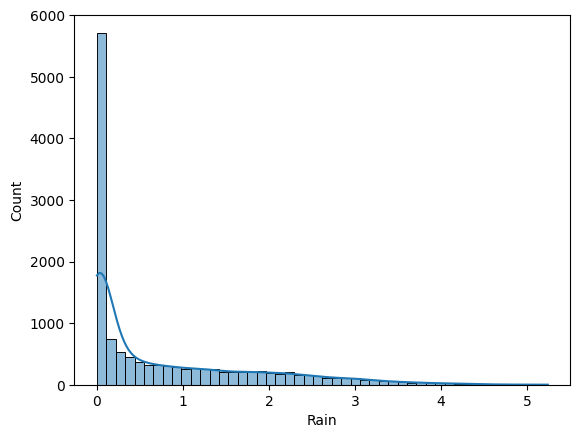

In [ ]:
sns.histplot(df_cleaned['Rain'], kde=True)
plt.show()

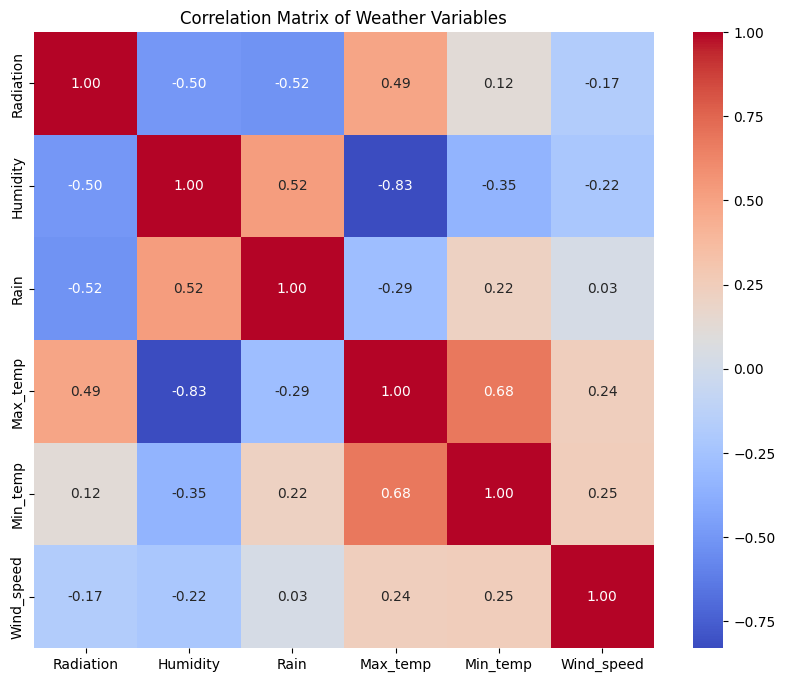

In [ ]:
df_numerical = df_cleaned.drop(columns=['Date'])
correlation_matrix = df_numerical.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Weather Variables')
plt.show()

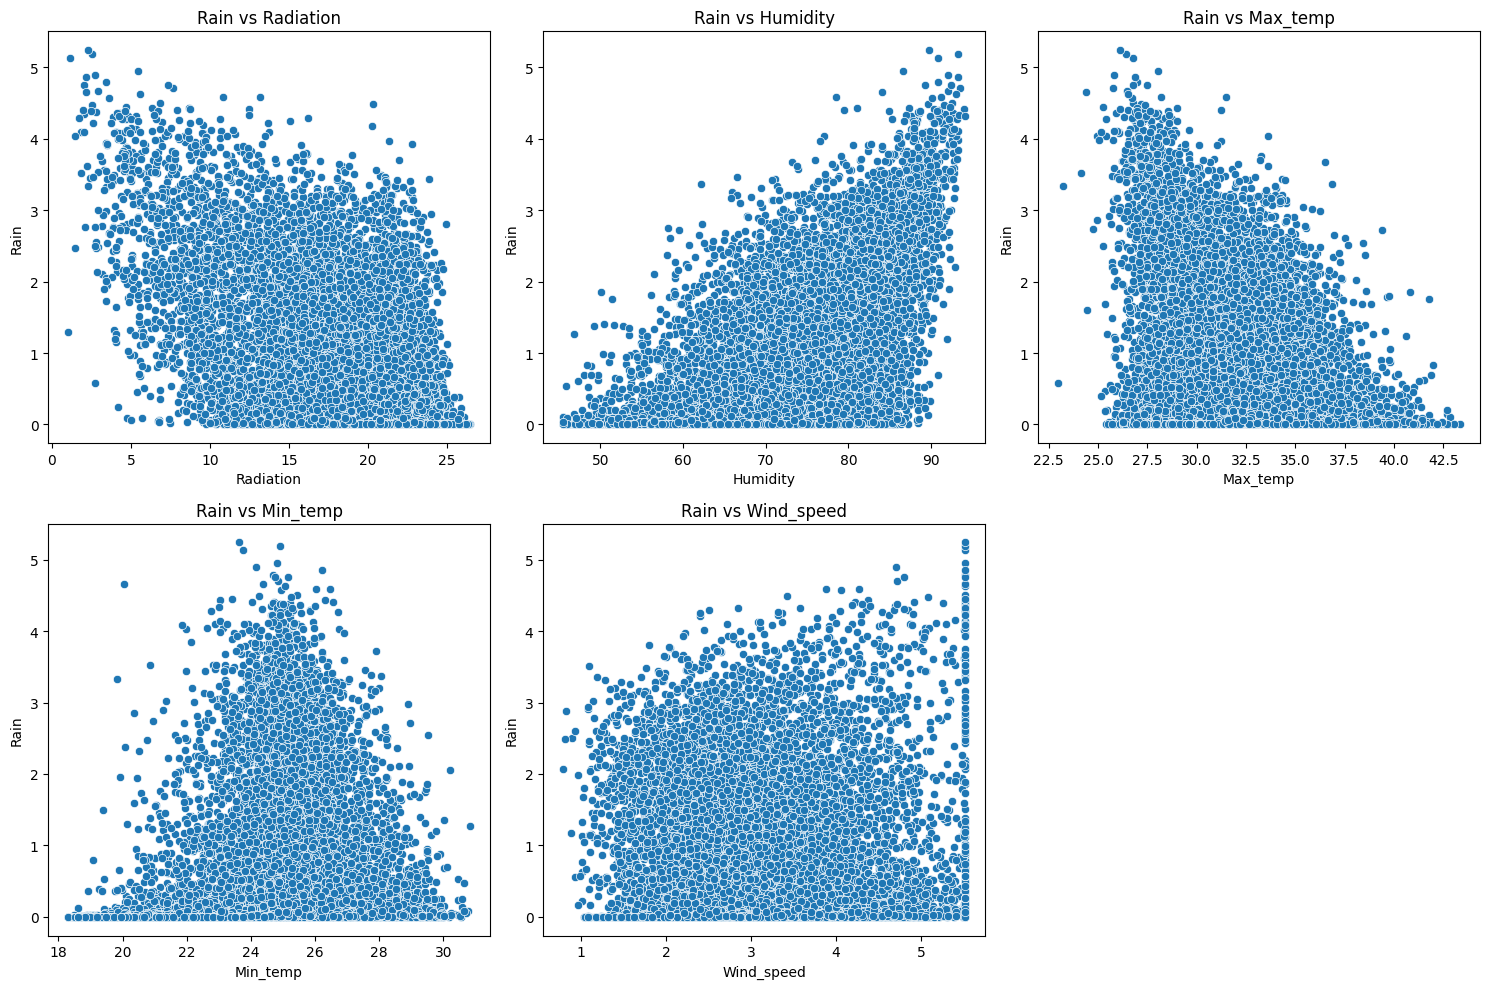

In [ ]:
numerical_features = df_numerical.columns.drop('Rain')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.scatterplot(x=df_cleaned[col], y=df_cleaned['Rain'])
    plt.title(f'Rain vs {col}')
    plt.xlabel(col)
    plt.ylabel('Rain')
plt.tight_layout()
plt.show()

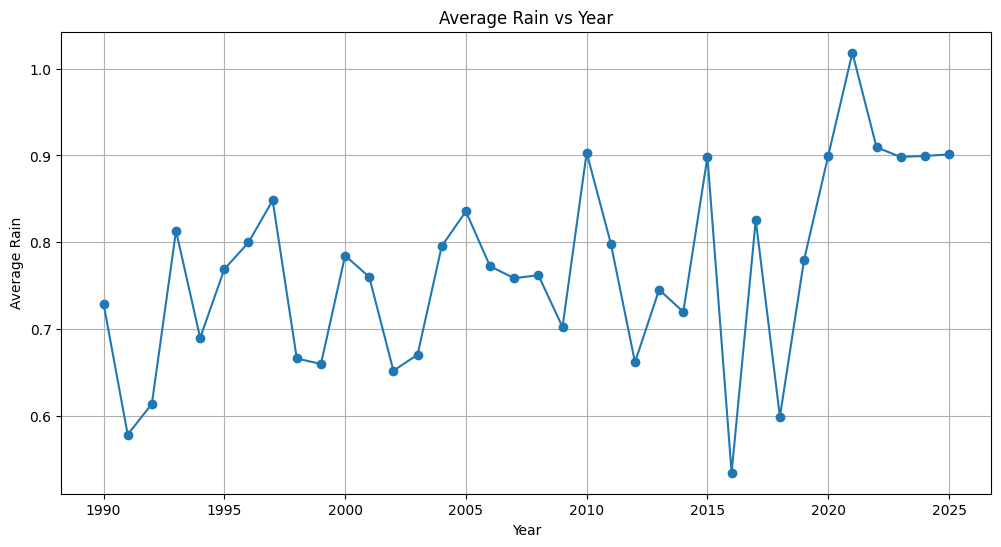

In [ ]:
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
df_cleaned['Year'] = df_cleaned['Date'].dt.year
df_cleaned['Month'] = df_cleaned['Date'].dt.month

plt.figure(figsize=(12, 6))
df_cleaned.groupby('Year')['Rain'].mean().plot(kind='line', marker='o')
plt.title('Average Rain vs Year')
plt.xlabel('Year')
plt.ylabel('Average Rain')
plt.grid(True)
plt.show()

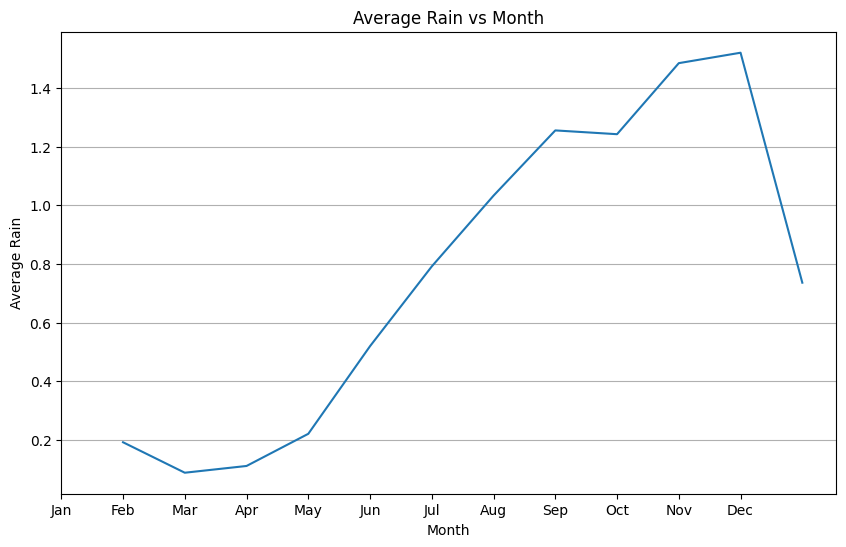

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Month', y='Rain', data=df_cleaned, ci=None)
plt.title('Average Rain vs Month')
plt.xlabel('Month')
plt.ylabel('Average Rain')
plt.xticks(ticks=__builtins__.range(0,12),labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(axis='y')
plt.show()

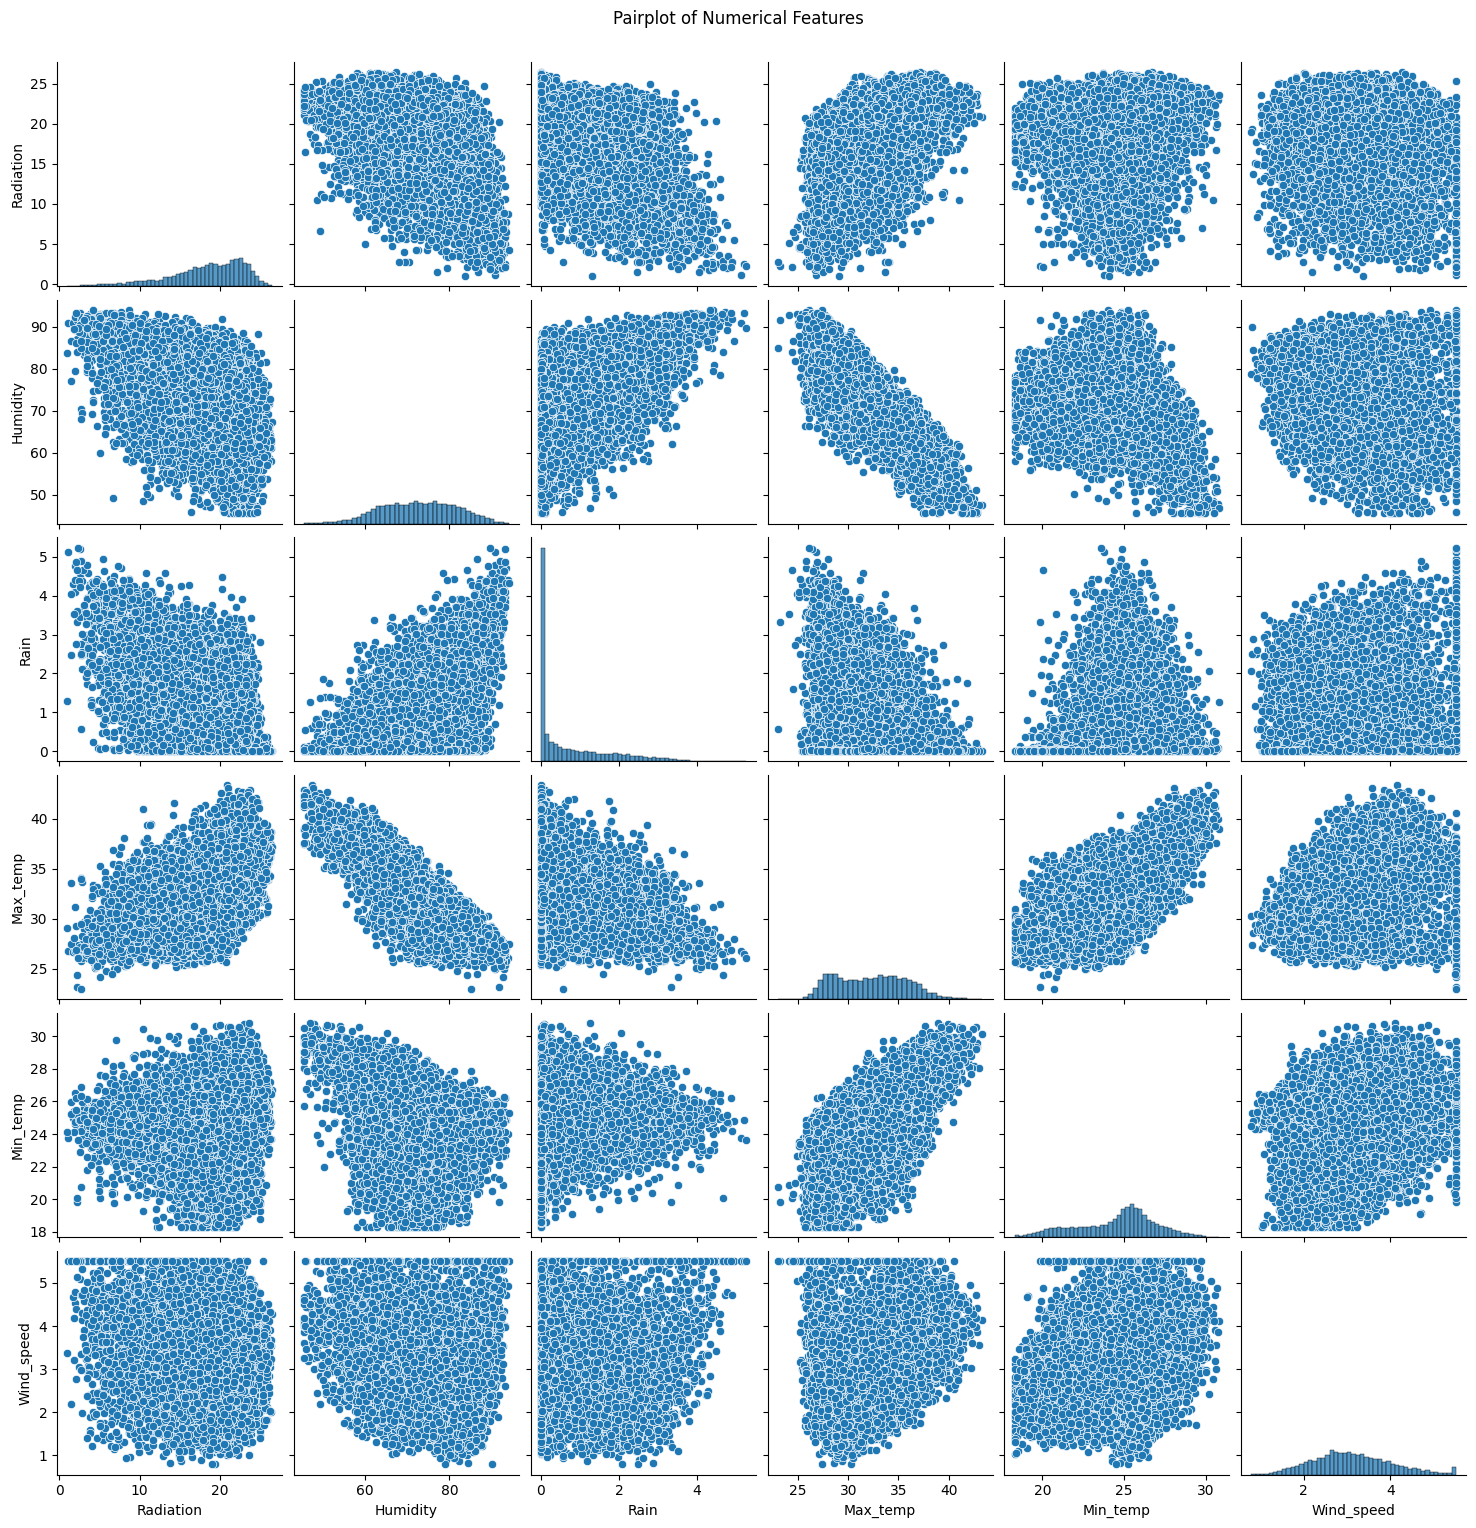

In [ ]:
sns.pairplot(df_numerical)
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

### Normalization

In [ ]:
def metrics(y_test, y_pred, X_train, y_train):
        def metrics_some(y_test, y_pred):
          r2 = r2_score(y_test, y_pred)
          mae = mean_absolute_error(y_test, y_pred)
          mse = mean_squared_error(y_test, y_pred)
          return r2, mae, mse
        def mallows_cp(y_train, X_train):
          full_model = LinearRegression()
          full_model.fit(X_train, y_train)
          y_train_pred = full_model.predict(X_train)
          sigma2 = mean_squared_error(y_train, y_train_pred)
          n = len(y_train)
          p = X_train.shape[1]
          rss = np.sum((y_train - y_train_pred) ** 2)
          cp = (rss / sigma2) - (n - 2 * p)
          return cp
        r2, mae, mse = metrics_some(y_test, y_pred)
        cp = mallows_cp(y_train, X_train)
        metrics_df = pd.DataFrame({'Metric': ['R2','MAE','MSE', "Mallow Cp"],
                                   'Value': [r2, mae, mse, cp]})
        return metrics_df

In [ ]:
num_cols = df_cleaned.drop(columns=['Date','Year','Month']).columns
X=df_cleaned.drop(columns=['Rain', 'Date', 'Year', 'Month'])
y=df_cleaned['Rain']
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

#### Min - Max Normalization

In [ ]:
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm  = scaler_mm.transform(X_test)

In [ ]:
lr_mm = LinearRegression()
lr_mm.fit(X_train_mm, y_train)

LinearRegression()

In [ ]:
y_pred_mm=lr_mm.predict(X_test_mm)
pd.options.display.float_format = '{:.6f}'.format
metrics_df_mm = metrics(y_test, y_pred_mm, X_train_mm, y_train)
print(metrics_df_mm)

      Metric     Value
0         R2  0.527350
1        MAE  0.541087
2        MSE  0.489629
3  Mallow Cp 10.000000


#### Standard Normalization

In [ ]:
scaler_sn=StandardScaler()
X_train_sn=scaler_sn.fit_transform(X_train)
X_test_sn=scaler_sn.transform(X_test)

In [ ]:
lr_sn= LinearRegression()
lr_sn.fit(X_train_sn, y_train)

LinearRegression()

In [ ]:
y_pred_sn=lr_sn.predict(X_test_sn)
pd.options.display.float_format = '{:.6f}'.format
metrics_df_sn = metrics(y_test, y_pred_sn, X_train_sn, y_train)
print(metrics_df_sn)

      Metric     Value
0         R2  0.527350
1        MAE  0.541087
2        MSE  0.489629
3  Mallow Cp 10.000000


#### Robust Normalization

In [ ]:
scaler_robust = RobustScaler()
X_train_robust = scaler_robust.fit_transform(X_train)
X_test_robust = scaler_robust.transform(X_test)

In [ ]:
lr_robust = LinearRegression()
lr_robust.fit(X_train_robust, y_train)

LinearRegression()

In [ ]:
y_pred_robust = lr_robust.predict(X_test_robust)
pd.options.display.float_format = '{:.6f}'.format
metrics_df_robust = metrics(y_test, y_pred_robust, X_train_robust, y_train)
print(metrics_df_robust)

      Metric     Value
0         R2  0.527350
1        MAE  0.541087
2        MSE  0.489629
3  Mallow Cp 10.000000


In [ ]:
co_efs=pd.DataFrame({
    'Feature': X.columns,
    'Coef_Min-Max': lr_mm.coef_,
    'Coef_Standard': lr_sn.coef_,
    'Coef_robust': lr_robust.coef_,})
print("Coefficients of the Techniques:")
display(co_efs)
intercepts_df = pd.DataFrame({
    'Normalization Technique': ['Min-Max Intercept', 'Standard Intercept',
                                'Robust Intercept'],
    'Value': [lr_mm.intercept_, lr_sn.intercept_,lr_robust.intercept_]})
print("\nIntercepts of the Techniques:")
display(intercepts_df)

Coefficients of the Techniques:


,Feature,Coef_Min-Max,Coef_Standard,Coef_robust
0,Radiation,-1.756619,-0.320958,-0.428748
1,Humidity,2.847272,0.528355,0.793902
2,Max_temp,0.133230,0.022978,0.038365
3,Min_temp,2.289266,0.433331,0.579630
4,Wind_speed,-0.136181,-0.025953,-0.034874



Intercepts of the Techniques:


,Normalization Technique,Value
0,Min-Max Intercept,-0.762335
1,Standard Intercept,0.765235
2,Robust Intercept,0.809633
